# Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Part 1 - Payoff Matrix & State Probabilities

In [2]:
# Calibrated parameters based on the benchmark dataset:
# A = 750, B = 300, C = 0.3
products = [f"Product {i}" for i in range(1, 7)]
states = ["Low Demand (S1)", "Medium Demand (S2)", "High Demand (S3)"]
probabilities = np.array([0.31, 0.45, 0.24])

# Payoff matrix (Million Tomans)
payoff_data = np.array([
    [1050.0, 1500.0, 2100.0],  # P1
    [1350.0,  750.0, 2400.0],  # P2
    [1650.0, 1500.0, 2850.0],  # P3
    [1200.0,  750.0, 1800.0],  # P4
    [1500.0, 1125.0, 2700.0],  # P5
    [1800.0, 1500.0, 2850.0]   # P6
])

df_payoff = pd.DataFrame(payoff_data, index=products, columns=states)
df_payoff.loc["Probability"] = probabilities
df_payoff

,Low Demand (S1),Medium Demand (S2),High Demand (S3)
Product 1,1050.0000,1500.0000,2100.0000
Product 2,1350.0000,750.0000,2400.0000
Product 3,1650.0000,1500.0000,2850.0000
Product 4,1200.0000,750.0000,1800.0000
Product 5,1500.0000,1125.0000,2700.0000
Product 6,1800.0000,1500.0000,2850.0000
Probability,0.3100,0.4500,0.2400


# Decision Making Under Complete Uncertainty & Risk Function

In [4]:
def evaluate_decision_criteria(payoffs, probs=None, alpha=0.5):
    """
    Computes Maximax, Maximin, Hurwicz, Savage Regret, Laplace, and Bayes (EMV).
    """
    n_alts = payoffs.shape[0]
    
    # 1. Maximax (Optimistic)
    maximax_vals = np.max(payoffs, axis=1)
    
    # 2. Maximin (Pessimistic / Wald)
    maximin_vals = np.min(payoffs, axis=1)
    
    # 3. Hurwicz Criterion
    hurwicz_vals = alpha * maximax_vals + (1 - alpha) * maximin_vals
    
    # 4. Laplace (Equal Likelihood)
    laplace_vals = np.mean(payoffs, axis=1)
    
    # 5. Savage Minimax Regret
    max_per_state = np.max(payoffs, axis=0)
    regret_matrix = max_per_state - payoffs
    max_regret = np.max(regret_matrix, axis=1)
    
    # 6. Bayes / EMV (if probabilities provided)
    emv_vals = np.dot(payoffs, probs) if probs is not None else None

    results = {
        "Maximax": maximax_vals,
        "Maximin": maximin_vals,
        f"Hurwicz (α={alpha})": hurwicz_vals,
        "Laplace": laplace_vals,
        "Minimax Regret": max_regret
    }
    if emv_vals is not None:
        results["Bayes (EMV)"] = emv_vals
        
    return pd.DataFrame(results, index=products), regret_matrix

# Run baseline evaluation
df_baseline, regret_mat = evaluate_decision_criteria(payoff_data, probabilities, alpha=0.5)
df_baseline

,Maximax,Maximin,Hurwicz (α=0.5),Laplace,Minimax Regret,Bayes (EMV)
Product 1,2100.0000,1050.0000,1575.0000,1550.0000,750.0000,1504.5000
Product 2,2400.0000,750.0000,1575.0000,1500.0000,750.0000,1332.0000
Product 3,2850.0000,1500.0000,2175.0000,2000.0000,150.0000,1870.5000
Product 4,1800.0000,750.0000,1275.0000,1250.0000,1050.0000,1141.5000
Product 5,2700.0000,1125.0000,1912.5000,1775.0000,375.0000,1619.2500
Product 6,2850.0000,1500.0000,2175.0000,2050.0000,0.0000,1917.0000


# Visualizing Opportunity Loss (Regret Matrix) & Hurwicz Sensitivity

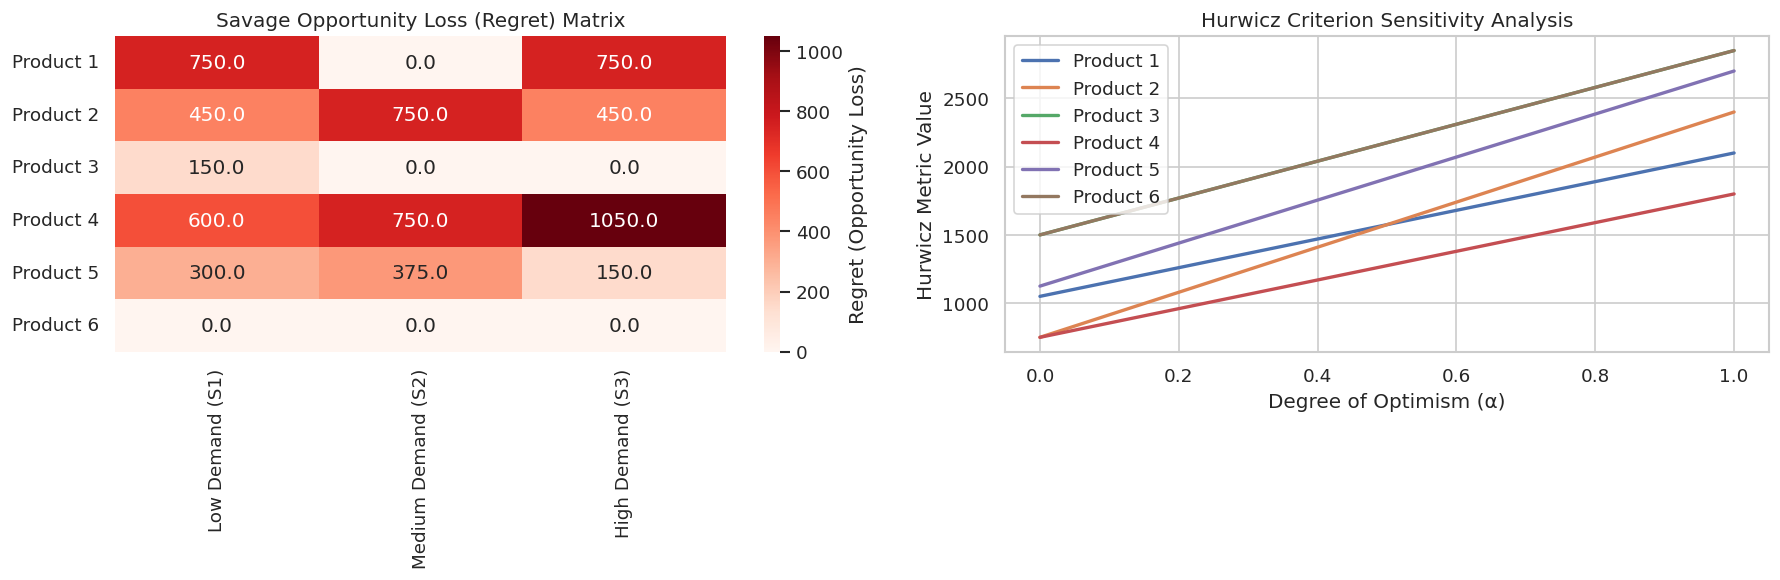

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Regret Heatmap
df_regret = pd.DataFrame(regret_mat, index=products, columns=states)
sns.heatmap(df_regret, annot=True, fmt=".1f", cmap="Reds", ax=axes[0], cbar_kws={'label': 'Regret (Opportunity Loss)'})
axes[0].set_title("Savage Opportunity Loss (Regret) Matrix")

# 2. Hurwicz Sensitivity Plot across alpha in [0, 1]
alphas = np.linspace(0, 1, 101)
for i, prod in enumerate(products):
    h_curve = alphas * np.max(payoff_data[i]) + (1 - alphas) * np.min(payoff_data[i])
    axes[1].plot(alphas, h_curve, label=prod, linewidth=2)

axes[1].set_xlabel("Degree of Optimism (α)")
axes[1].set_ylabel("Hurwicz Metric Value")
axes[1].set_title("Hurwicz Criterion Sensitivity Analysis")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

# Sensitivity Analysis (Production Manager's Revisions)

In [6]:
# Manager asserts:
# P1 - P3 were underestimated by 30% -> true value = value * 1.30
# P4 - P6 were overestimated by 30% -> true value = value * 0.70
payoff_revised = payoff_data.copy()
payoff_revised[0:3, :] *= 1.30  # P1 - P3
payoff_revised[3:6, :] *= 0.70  # P4 - P6

df_revised, _ = evaluate_decision_criteria(payoff_revised, probabilities, alpha=0.5)

# Comparison of Optimal Decisions (Before vs. After)
def get_best_choices(df):
    best = {}
    for col in df.columns:
        if "Regret" in col:
            best[col] = df[col].idxmin()
        else:
            best[col] = df[col].idxmax()
    return pd.Series(best)

df_decision_shifts = pd.DataFrame({
    "Original Optimal Choice": get_best_choices(df_baseline),
    "Revised Optimal Choice (Manager Shift)": get_best_choices(df_revised)
})
df_decision_shifts

,Original Optimal Choice,Revised Optimal Choice (Manager Shift)
Maximax,Product 3,Product 3
Maximin,Product 3,Product 3
Hurwicz (α=0.5),Product 3,Product 3
Laplace,Product 6,Product 3
Minimax Regret,Product 6,Product 3
Bayes (EMV),Product 6,Product 3


# Part 2 - Normalization of Multi-Attribute Decision Matrix

In [7]:
zones = [f"Zone {i}" for i in range(1, 7)]
criteria = ["Price (C1-)", "Market Access (C2-)", "Traffic (C3-)", "Parks (C4+)", "Transit (C5+)"]
criteria_types = np.array([-1, -1, -1, 1, 1])  # -1 for Cost, 1 for Benefit

# Quantitative Mapping for Linguistic Scales (1 to 10)
linguistic_scale = {
    "Very Close": 2, "Close": 4, "Moderately Close": 5, "Moderately Far": 7, "Far": 9,
    "Low": 2, "Medium": 5, "Moderately High": 7, "High": 8,
    "Moderately Low": 4, "Very High": 9
}

# Raw Matrix Construction
raw_matrix = np.array([
    [3000, linguistic_scale["Close"],           linguistic_scale["High"],            5, linguistic_scale["High"]],
    [6000, linguistic_scale["Far"],             linguistic_scale["Moderately High"], 3, linguistic_scale["Very High"]],
    [6750, linguistic_scale["Moderately Close"], linguistic_scale["Medium"],          4, linguistic_scale["Moderately Low"]],
    [2250, linguistic_scale["Very Close"],       linguistic_scale["Low"],             2, linguistic_scale["Medium"]],
    [5250, linguistic_scale["Moderately Far"],   linguistic_scale["High"],            6, linguistic_scale["Low"]],
    [4500, linguistic_scale["Very Close"],       linguistic_scale["Low"],             4, linguistic_scale["Moderately High"]],
], dtype=float)

target_vector = np.array([3750, linguistic_scale["Close"], linguistic_scale["Low"], 4, linguistic_scale["Medium"]], dtype=float)

df_raw = pd.DataFrame(raw_matrix, index=zones, columns=criteria)
df_raw

,Price (C1-),Market Access (C2-),Traffic (C3-),Parks (C4+),Transit (C5+)
Zone 1,3000.0000,4.0000,8.0000,5.0000,8.0000
Zone 2,6000.0000,9.0000,7.0000,3.0000,9.0000
Zone 3,6750.0000,5.0000,5.0000,4.0000,4.0000
Zone 4,2250.0000,2.0000,2.0000,2.0000,5.0000
Zone 5,5250.0000,7.0000,8.0000,6.0000,2.0000
Zone 6,4500.0000,2.0000,2.0000,4.0000,7.0000


# Implementing 6 Normalization Techniques

In [8]:
X = raw_matrix.copy()
m, n = X.shape

# 1. Vector (Euclidean) Normalization
norm_vector = X / np.sqrt(np.sum(X**2, axis=0))

# 2. Linear Sum Normalization (Directional)
norm_linear_sum = np.zeros_like(X)
for j in range(n):
    if criteria_types[j] == 1:  # Benefit
        norm_linear_sum[:, j] = X[:, j] / np.sum(X[:, j])
    else:  # Cost
        inv = 1.0 / X[:, j]
        norm_linear_sum[:, j] = inv / np.sum(inv)

# 3. Linear Max Normalization
norm_linear_max = np.zeros_like(X)
for j in range(n):
    if criteria_types[j] == 1:
        norm_linear_max[:, j] = X[:, j] / np.max(X[:, j])
    else:
        norm_linear_max[:, j] = np.min(X[:, j]) / X[:, j]

# 4. Fuzzy Range (Min-Max) Normalization [0, 1]
norm_min_max = np.zeros_like(X)
for j in range(n):
    min_v, max_v = np.min(X[:, j]), np.max(X[:, j])
    if criteria_types[j] == 1:
        norm_min_max[:, j] = (X[:, j] - min_v) / (max_v - min_v)
    else:
        norm_min_max[:, j] = (max_v - X[:, j]) / (max_v - min_v)

# 5. Standard Normal (Z-score)
norm_zscore = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 6. Centroid (Distance-to-Target) Normalization
norm_target = 1.0 - np.abs(X - target_vector) / (np.max(X, axis=0) - np.min(X, axis=0))

print("All 6 normalizations completed successfully.")
pd.DataFrame(norm_min_max, index=zones, columns=criteria)  # Displaying Min-Max as an example

All 6 normalizations completed successfully.


,Price (C1-),Market Access (C2-),Traffic (C3-),Parks (C4+),Transit (C5+)
Zone 1,0.8333,0.7143,0.0000,0.7500,0.8571
Zone 2,0.1667,0.0000,0.1667,0.2500,1.0000
Zone 3,0.0000,0.5714,0.5000,0.5000,0.2857
Zone 4,1.0000,1.0000,1.0000,0.0000,0.4286
Zone 5,0.3333,0.2857,0.0000,1.0000,0.0000
Zone 6,0.5000,1.0000,1.0000,0.5000,0.7143


# Weighting Methods - Shannon Entropy & Prior Integration

In [9]:
# Objective Shannon Entropy Calculation
P = X / np.sum(X, axis=0)  # Frequency matrix
k = 1.0 / np.log(m)

# Entropy per criterion
entropy = -k * np.sum(P * np.log(P + 1e-12), axis=0)
diversification = 1.0 - entropy
w_entropy_objective = diversification / np.sum(diversification)

# Subjective prior beliefs w0
w_prior = np.array([0.15, 0.05, 0.20, 0.10, 0.50])

# Subjective-Objective Integration
w_entropy_combined = (w_prior * w_entropy_objective) / np.sum(w_prior * w_entropy_objective)

df_entropy = pd.DataFrame({
    "Entropy (Ej)": entropy,
    "Diversification (dj)": diversification,
    "Objective Weight (wj)": w_entropy_objective,
    "Prior Belief (w0)": w_prior,
    "Combined Weight (wj*)": w_entropy_combined
}, index=criteria)
df_entropy

,Entropy (Ej),Diversification (dj),Objective Weight (wj),Prior Belief (w0),Combined Weight (wj*)
Price (C1-),0.9651,0.0349,0.1302,0.1500,0.0991
Market Access (C2-),0.9217,0.0783,0.2922,0.0500,0.0742
Traffic (C3-),0.9277,0.0723,0.2696,0.2000,0.2737
Parks (C4+),0.9698,0.0302,0.1127,0.1000,0.0572
Transit (C5+),0.9476,0.0524,0.1954,0.5000,0.4958


# Weighting Methods - SWARA (Step-wise Weight Assessment Ratio Analysis)

In [10]:
# Survey votes: C1=180, C2=12, C3=18, C4=6, C5=9
swara_votes = pd.Series([180, 12, 18, 6, 9], index=criteria, name="Votes")

# Step 1: Rank criteria based on importance (Votes)
swara_df = pd.DataFrame(swara_votes).sort_values(by="Votes", ascending=False)

# Step 2: Comparative significance (s_j) derived from relative vote ratio differences
# For first criterion: s_1 = 0
s_j = [0.0]
for i in range(1, len(swara_df)):
    diff_ratio = (swara_df["Votes"].iloc[i-1] - swara_df["Votes"].iloc[i]) / swara_df["Votes"].iloc[i-1]
    s_j.append(diff_ratio)
swara_df["Comparative Significance (s_j)"] = s_j

# Step 3: Coefficient k_j = s_j + 1
swara_df["Coefficient (k_j)"] = swara_df["Comparative Significance (s_j)"] + 1.0
swara_df["Coefficient (k_j)"].iloc[0] = 1.0

# Step 4: Recalculated weight q_j
q_j = [1.0]
for i in range(1, len(swara_df)):
    q_j.append(q_j[i-1] / swara_df["Coefficient (k_j)"].iloc[i])
swara_df["Recalculated Weight (q_j)"] = q_j

# Step 5: Final Relative Weights (w_j)
swara_df["SWARA Weight (w_j)"] = swara_df["Recalculated Weight (q_j)"] / swara_df["Recalculated Weight (q_j)"].sum()

swara_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16576\2239822228.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  swara_df["Coefficient (k_j)"].iloc[0] = 1.0
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16576\2239822228.py:17: SettingWithCo

,Votes,Comparative Significance (s_j),Coefficient (k_j),Recalculated Weight (q_j),SWARA Weight (w_j)
Price (C1-),180,0.0000,1.0000,1.0000,0.4043
Traffic (C3-),18,0.9000,1.9000,0.5263,0.2128
Market Access (C2-),12,0.3333,1.3333,0.3947,0.1596
Transit (C5+),9,0.2500,1.2500,0.3158,0.1277
Parks (C4+),6,0.3333,1.3333,0.2368,0.0957


# Comparative Visualization of Criteria Weights

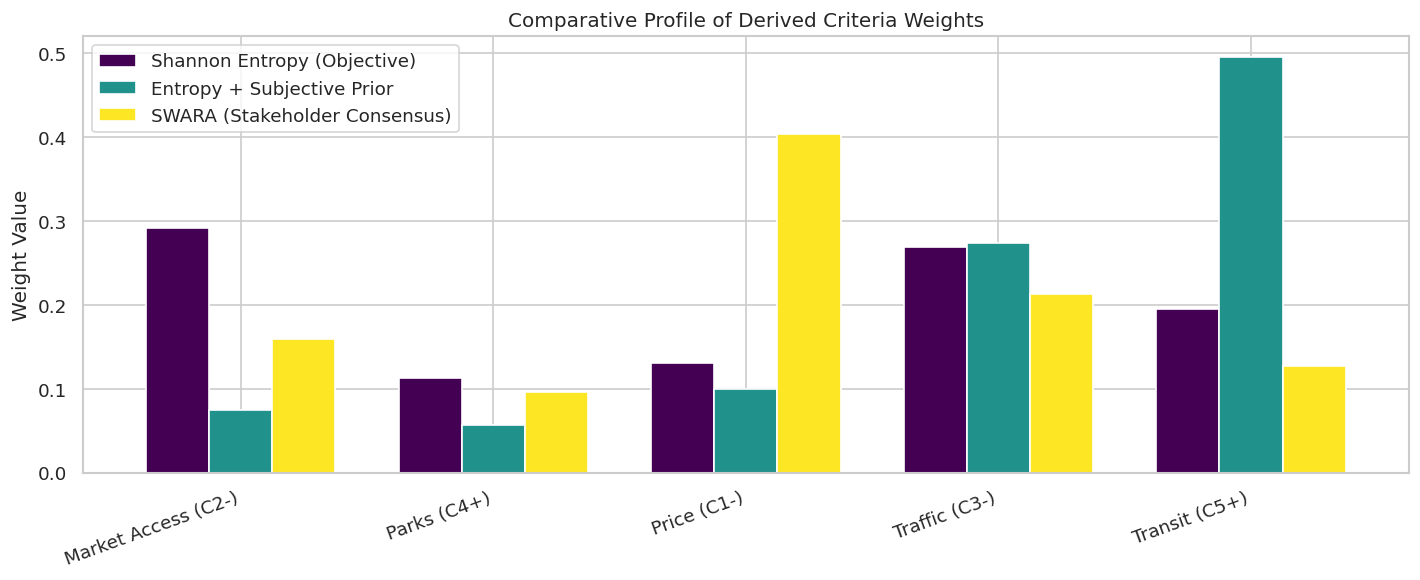

In [11]:
weights_comparison = pd.DataFrame({
    "Shannon Entropy (Objective)": df_entropy["Objective Weight (wj)"],
    "Entropy + Subjective Prior": df_entropy["Combined Weight (wj*)"],
    "SWARA (Stakeholder Consensus)": swara_df["SWARA Weight (w_j)"]
}).fillna(0)

weights_comparison.plot(kind="bar", figsize=(12, 5), width=0.75, colormap="viridis")
plt.title("Comparative Profile of Derived Criteria Weights")
plt.ylabel("Weight Value")
plt.xticks(rotation=20, ha='right')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()